# Baseline: TF-IDF + Logistic Regression

Fast, interpretable baseline before touching any neural network.  
Goal: establish a macro-F1 floor that the fine-tuned model must beat.

**Classes:** `bug` | `feature` | `docs` | `question`  
**Train/val/test split:** 70 / 15 / 15 (chronological)

In [11]:
import os
import sys

sys.path.insert(0, os.path.abspath('../data'))

import pickle
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline

SPLITS = '../data/splits'
CLASSES = ['bug', 'feature', 'docs', 'question']

## 1. Load Data

In [12]:
train = pd.read_parquet(f'{SPLITS}/train.parquet')
val   = pd.read_parquet(f'{SPLITS}/val.parquet')
test  = pd.read_parquet(f'{SPLITS}/test.parquet')

print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')
train.head(3)

Train: 1,862  Val: 399  Test: 401


,id,title,body,labels,created_at,closed_at,mapped_label
0,51963696,Support for managing multiple rooms or groups ...,I suspect this either hasn't been considered y...,[enhancement],2014-12-15 09:17:47+00:00,2015-03-16T07:48:56Z,feature
1,54789332,support for z-wave usb sticks,Controlling and reading z-wave devices via a z...,[enhancement],2015-01-19 17:12:46+00:00,2015-03-01T07:29:28Z,feature
2,56928318,Control thermostat from web interface,Nice work with the new design for the web inte...,[enhancement],2015-02-07 22:15:16+00:00,2015-03-02T16:13:02Z,feature


## 2. EDA

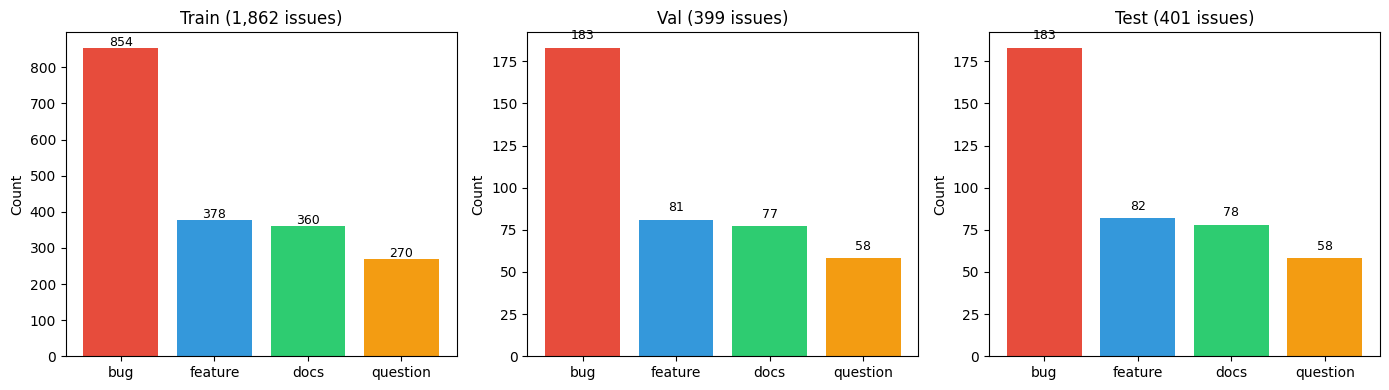


Train distribution:
mapped_label
bug         854
feature     378
docs        360
question    270
Name: count, dtype: int64


In [13]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (df, name) in zip(axes, [(train, 'Train'), (val, 'Val'), (test, 'Test')]):
    counts = df['mapped_label'].value_counts().reindex(CLASSES, fill_value=0)
    ax.bar(counts.index, counts.values, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
    ax.set_title(f'{name} ({len(df):,} issues)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTrain distribution:')
print(train['mapped_label'].value_counts())

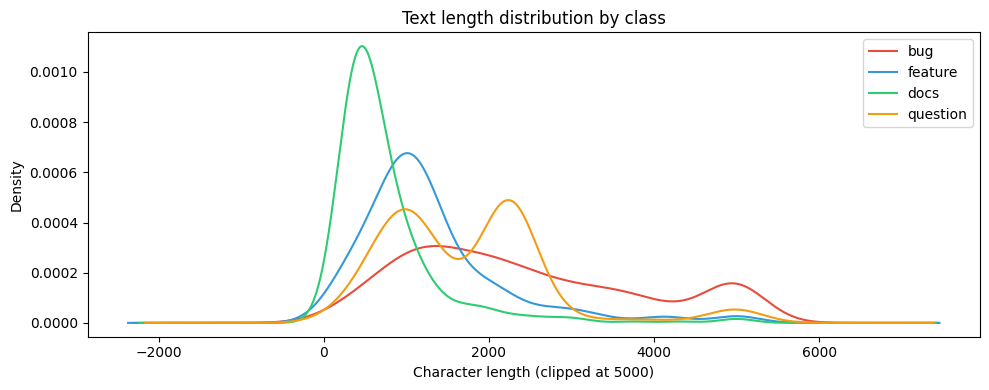

                mean     50%       max
mapped_label                          
bug           3817.0  2085.0  128300.0
docs           775.0   548.0    9095.0
feature       1504.0  1082.0   43893.0
question      2106.0  1636.0   32421.0


In [14]:
# Text length distribution
train['text_len'] = (train['title'] + ' ' + train['body']).str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in zip(CLASSES, ['#e74c3c','#3498db','#2ecc71','#f39c12']):
    subset = train[train['mapped_label'] == label]['text_len']
    subset.clip(upper=5000).plot.kde(ax=ax, label=label, color=color)
ax.set_xlabel('Character length (clipped at 5000)')
ax.set_title('Text length distribution by class')
ax.legend()
plt.tight_layout()
plt.show()

print(train.groupby('mapped_label')['text_len'].describe()[['mean','50%','max']].round(0))

## 3. Feature Engineering

Concatenate title + body. Title carries strong signal (class labels in the issue title are common).

In [15]:
def make_text(df: pd.DataFrame) -> pd.Series:
    return (df['title'].fillna('') + ' ' + df['body'].fillna('')).str.strip()

X_train, y_train = make_text(train), train['mapped_label']
X_val,   y_val   = make_text(val),   val['mapped_label']
X_test,  y_test  = make_text(test),  test['mapped_label']

print(f'Sample: {X_train.iloc[0][:120]}...')

Sample: Support for managing multiple rooms or groups of lights I suspect this either hasn't been considered yet, or it's still ...


## 4. Model: TF-IDF + Logistic Regression

`class_weight='balanced'` compensates for the docs class scarcity.

In [16]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial',
    )),
])

pipeline.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 5. Evaluation

In [17]:
def evaluate(pipeline, X, y, split_name: str):
    y_pred = pipeline.predict(X)
    accuracy = accuracy_score(y, y_pred)
    macro_f1 = f1_score(y, y_pred, average='macro')
    print(f'\n── {split_name} ──')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Macro F1:  {macro_f1:.4f}')
    print(classification_report(y, y_pred, target_names=CLASSES, zero_division=0))
    return y_pred, macro_f1, accuracy

_, val_macro_f1, val_accuracy                    = evaluate(pipeline, X_val,  y_val,  'Validation')
y_test_pred, test_macro_f1, test_accuracy        = evaluate(pipeline, X_test, y_test, 'Test')


── Validation ──
Accuracy:  0.6566
Macro F1:  0.5797
              precision    recall  f1-score   support

         bug       0.93      0.58      0.72       183
     feature       1.00      0.97      0.99        77
        docs       0.39      0.96      0.55        81
    question       0.25      0.03      0.06        58

    accuracy                           0.66       399
   macro avg       0.64      0.64      0.58       399
weighted avg       0.73      0.66      0.64       399


── Test ──
Accuracy:  0.5835
Macro F1:  0.5382
              precision    recall  f1-score   support

         bug       0.87      0.50      0.63       183
     feature       0.93      0.86      0.89        78
        docs       0.33      0.87      0.48        82
    question       0.56      0.09      0.15        58

    accuracy                           0.58       401
   macro avg       0.67      0.58      0.54       401
weighted avg       0.72      0.58      0.58       401



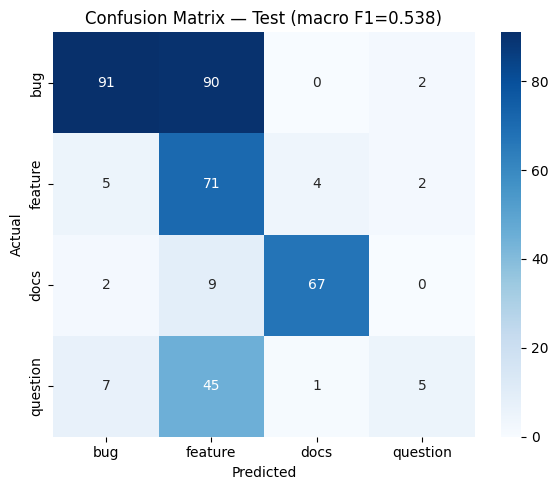

In [18]:
# Confusion matrix on test set
cm = confusion_matrix(y_test, y_test_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Test (macro F1={test_macro_f1:.3f})')
plt.tight_layout()
plt.show()

## 6. Threshold Check

Compare against `eval_thresholds.yaml` gates.

In [19]:
import yaml

with open('../../eval_thresholds.yaml') as f:
    thresholds = yaml.safe_load(f)

gates = thresholds['classification']
report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

print(f"Accuracy:  {test_accuracy:.3f}  (threshold: {gates['accuracy']})  {'PASS' if test_accuracy >= gates['accuracy'] else 'FAIL'}")
print(f"Macro F1:  {test_macro_f1:.3f}  (threshold: {gates['macro_f1']})  {'PASS' if test_macro_f1 >= gates['macro_f1'] else 'FAIL'}")
for cls in CLASSES:
    f1 = report.get(cls, {}).get('f1-score', 0)
    thr = gates['per_class'].get(cls, 0)
    status = 'PASS' if f1 >= thr else 'FAIL'
    print(f"  {cls:<10} F1: {f1:.3f}  (threshold: {thr})  {status}")

Accuracy:  0.584  (threshold: 0.7)  FAIL
Macro F1:  0.538  (threshold: 0.7)  FAIL
  bug        F1: 0.632  (threshold: 0.65)  FAIL
  feature    F1: 0.478  (threshold: 0.65)  FAIL
  docs       F1: 0.893  (threshold: 0.6)  PASS
  question   F1: 0.149  (threshold: 0.65)  FAIL


## 7. Save Model

In [20]:
os.makedirs('.', exist_ok=True)
with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print('Saved model.pkl')
print('\nBaseline results (test set):')
print(f'  Accuracy: {test_accuracy:.4f}')
print(f'  Macro F1: {test_macro_f1:.4f}')
print('This is the floor — the fine-tuned model must beat it.')

Saved model.pkl

Baseline results (test set):
  Accuracy: 0.5835
  Macro F1: 0.5382
This is the floor — the fine-tuned model must beat it.
